# 11. Interpretabilidad de Modelos de Machine Learning y Deep Learning

Este notebook explora técnicas modernas de interpretabilidad de modelos, incluyendo SHAP, LIME e importancia de características.

## Objetivo
- Comprender la importancia de la interpretabilidad en ML.
- Implementar y visualizar SHAP, LIME e importancia de características.
- Aprender a comunicar resultados de interpretabilidad.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [01](./01_intro_machine_learning.ipynb) y [03](./03_modelos_clasicos_ml.ipynb).

- Conceptos de modelos de clasificación, Random Forest, y métricas.

> ⚠️ **Dependencias adicionales:** `pip install shap lime`

## 1. Introducción teórica

La interpretabilidad permite entender **por qué** un modelo toma ciertas decisiones. Esto es esencial para:
- Validar y confiar en modelos antes de desplegarlos.
- Detectar sesgos y problemas en los datos.
- Cumplir con regulaciones (GDPR, IA responsable).

| Técnica | Alcance | Ventaja | Desventaja |
|---------|---------|---------|------------|
| **Feature Importance** | Global | Rápido, integrado en el modelo | Solo modelos de árboles |
| **SHAP** | Global + Local | Robusto, basado en teoría de juegos | Más costoso computacionalmente |
| **LIME** | Local | Rápido, agnóstico al modelo | Aproximación local, puede variar |

## 2. Importación de librerías

In [20]:
#!pip install shap lime

# === Reproducibilidad ===
import random
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 3. Entrenar un modelo de ejemplo

In [3]:
data = load_breast_cancer()
features = data.feature_names
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train, y_train)
print(f"Accuracy en test: {model.score(X_test, y_test):.2f}")

Accuracy en test: 0.96


## 4. Importancia de características

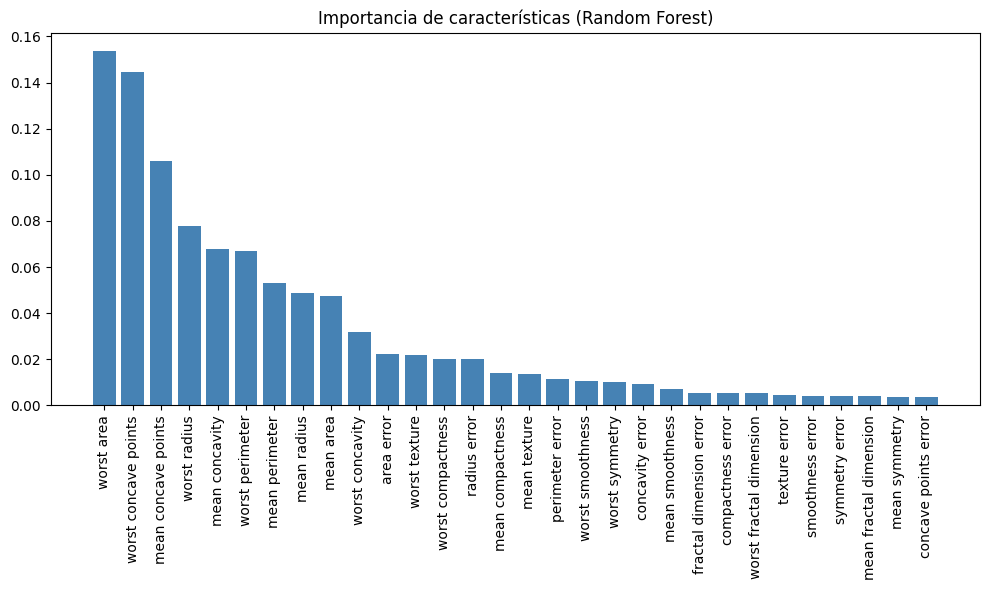

Top 5 variables más importantes:
  1. worst area: 0.1539
  2. worst concave points: 0.1447
  3. mean concave points: 0.1062
  4. worst radius: 0.0780
  5. mean concavity: 0.0680


In [4]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.title('Importancia de características (Random Forest)')
plt.tight_layout()
plt.show()

# Top 5
print('Top 5 variables más importantes:')
for i in range(5):
    print(f'  {i+1}. {features[indices[i]]}: {importances[indices[i]]:.4f}')

## 5. Explicaciones con SHAP

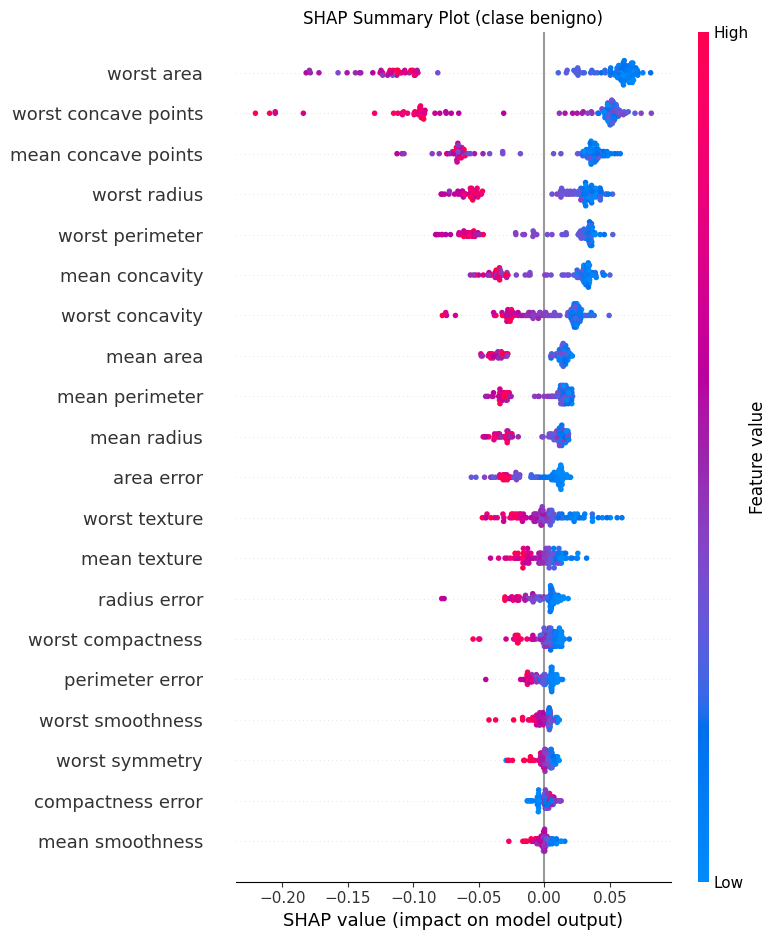

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot (importancia global con dirección del efecto)
# Para modelos de clasificación binaria, shap_values es una lista de arrays o un array 3D.
# Si es un array 3D de forma (num_samples, num_features, num_classes),
# seleccionamos la clase 1 (benigno) para todas las muestras y características.
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=features, show=False)
plt.title('SHAP Summary Plot (clase benigno)')
plt.tight_layout()
plt.show()

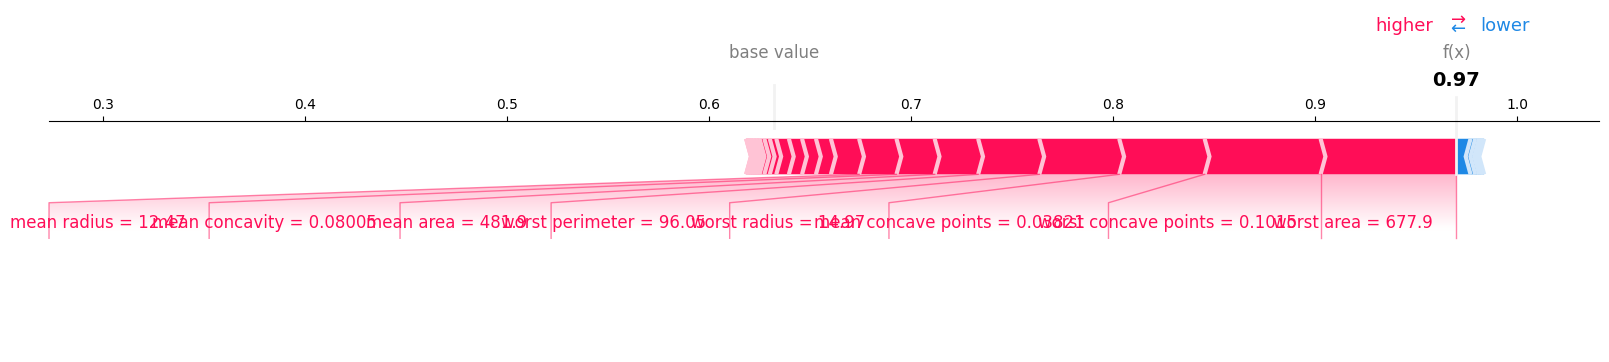

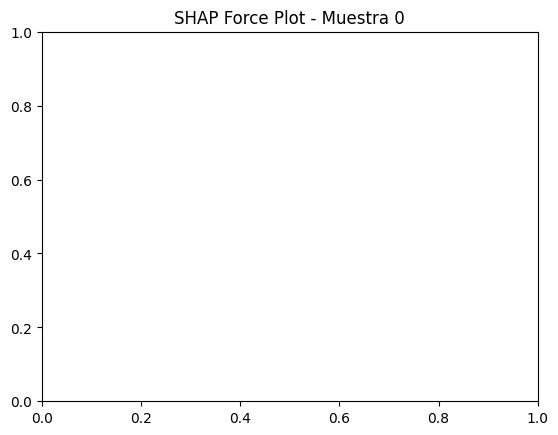

In [8]:
# Explicación local: primera muestra de test
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[0, :, 1], X_test[0],
                feature_names=features, matplotlib=True)
plt.title('SHAP Force Plot - Muestra 0')
plt.show()

## 6. Explicaciones con LIME

In [9]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train, feature_names=features,
    class_names=['Maligno', 'Benigno'],
    discretize_continuous=True)

# Explicar la primera predicción del test
exp = explainer_lime.explain_instance(X_test[0], model.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True, show_all=False)

## 7. Discusión y Conclusiones

- La interpretabilidad es esencial para validar y confiar en modelos.
- **Feature Importance** es rápido pero limitado a modelos de árboles.
- **SHAP** es el más robusto: muestra importancia global y explicaciones locales.
- **LIME** es rápido y agnóstico al modelo, ideal para explicaciones locales.
- Documenta y comunica los resultados de interpretabilidad a stakeholders.

## 8. Ejercicios Propuestos

1. **Ejercicio 1:** Aplica SHAP a un modelo diferente (GradientBoosting, XGBoost). ¿Cambian las variables importantes?

2. **Ejercicio 2:** Compara las explicaciones LIME para muestras correctamente e incorrectamente clasificadas.

3. **Ejercicio 3:** Usa `shap.dependence_plot` para explorar la relación entre una variable y su efecto en la predicción.

4. **Ejercicio 4 (Avanzado):** Aplica SHAP a una red neuronal de Keras usando `shap.DeepExplainer` o `shap.KernelExplainer`.

## Resolución de Ejercicios Propuestos

Vamos a abordar los ejercicios 1 y 4:

*   **Ejercicio 1:** Aplicar SHAP a un modelo diferente (GradientBoosting).
*   **Ejercicio 4:** Aplicar SHAP a una red neuronal de Keras usando `shap.KernelExplainer`.

### Ejercicio 1: Aplicar SHAP a un modelo diferente (GradientBoosting)

Ahora entrenaremos un modelo `GradientBoostingClassifier` y usaremos SHAP para analizar su interpretabilidad. Compararemos si las variables importantes cambian respecto al `RandomForestClassifier`.

In [17]:
# Entrenar un GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
gb_model.fit(X_train, y_train)

print(f"Accuracy en test (GradientBoosting): {gb_model.score(X_test, y_test):.2f}")

Accuracy en test (GradientBoosting): 0.96


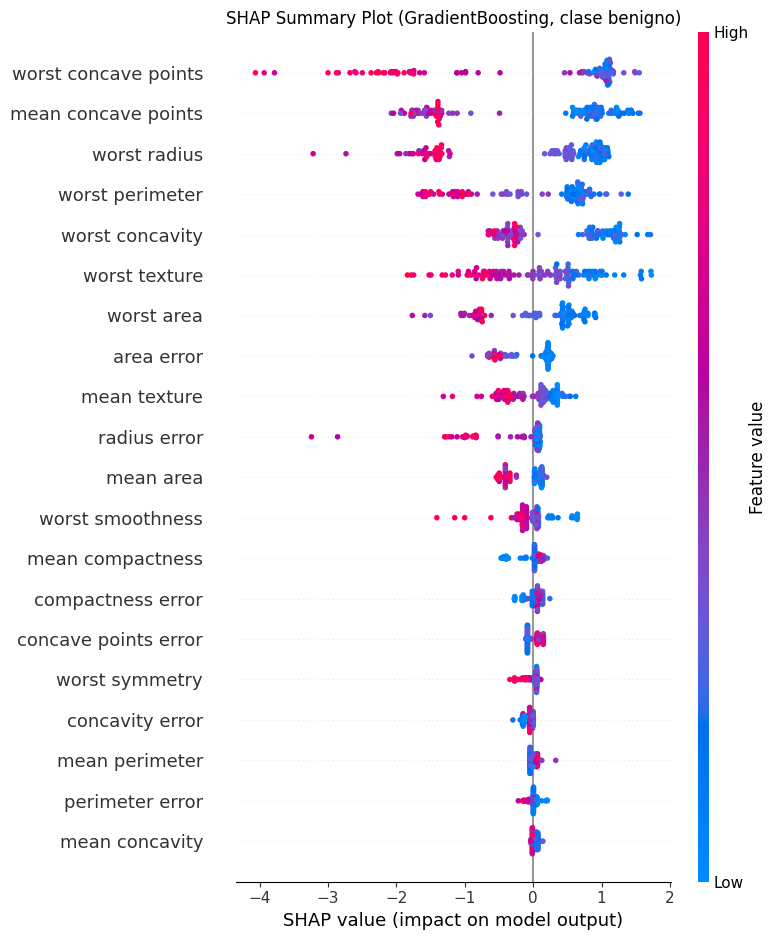

In [19]:
# Aplicar SHAP al GradientBoostingClassifier
explainer_gb = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb.shap_values(X_test)

# Summary plot para GradientBoosting
# shap_values_gb es una matriz 2D para clasificación binaria,
# por lo que no necesita indexación adicional para seleccionar la clase.
shap.summary_plot(shap_values_gb, X_test, feature_names=features, show=False)
plt.title('SHAP Summary Plot (GradientBoosting, clase benigno)')
plt.tight_layout()
plt.show()

### Ejercicio 4 (Avanzado): Aplicar SHAP a una red neuronal de Keras usando `shap.KernelExplainer`

Para este ejercicio, construiremos una red neuronal sencilla con Keras/TensorFlow, la entrenaremos y luego utilizaremos `shap.KernelExplainer` para interpretar sus predicciones. `KernelExplainer` es agnóstico al modelo y funciona bien con redes neuronales.

**Nota:** `DeepExplainer` es más rápido pero tiene requisitos específicos sobre la estructura de la red neuronal. `KernelExplainer` es más general y computacionalmente más intensivo, pero funciona con cualquier modelo.

In [21]:
# Estandarizar los datos para la red neuronal
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Construir la red neuronal
keras_model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid') # Salida binaria
])

keras_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
keras_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Entrenar la red neuronal
history = keras_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

loss, accuracy = keras_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Accuracy en test (Keras Neural Network): {accuracy:.2f}")

Accuracy en test (Keras Neural Network): 0.98


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━

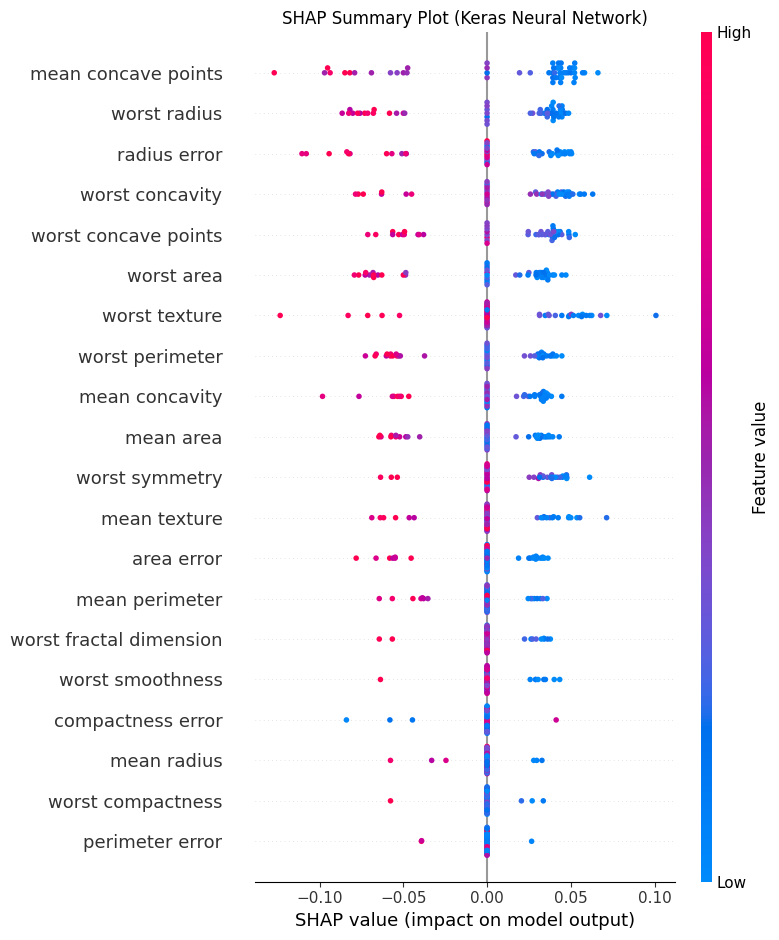

In [24]:
# Aplicar SHAP con KernelExplainer para la red neuronal
# KernelExplainer requiere una función de predicción y un 'background dataset'

# Función de predicción del modelo Keras
def predict_proba_keras(X):
    return keras_model.predict(X).flatten()

# Usamos una muestra del conjunto de entrenamiento como background dataset
# shap.kmeans es útil para seleccionar un conjunto representativo

# Reducir el tamaño del background dataset para KernelExplainer (puede ser lento)
# Tomaremos una muestra más pequeña o usaremos k-means para el background
background = shap.utils.sample(X_train_scaled, 100)

explainer_keras = shap.KernelExplainer(predict_proba_keras, background)

# Calcular los valores SHAP para un subconjunto de X_test_scaled (puede ser lento con muchos datos)
# Tomaremos las primeras 50 muestras de X_test para la explicación
shap_values_keras = explainer_keras.shap_values(X_test_scaled[:50])

# Summary plot para la red neuronal
shap.summary_plot(shap_values_keras, X_test_scaled[:50], feature_names=features, show=False)
plt.title('SHAP Summary Plot (Keras Neural Network)')
plt.tight_layout()
plt.show()

## Conclusión Final

### Comparación de modelos con SHAP (Ejercicio 1: Random Forest vs. Gradient Boosting)

Al aplicar SHAP a diferentes modelos basados en árboles (`RandomForestClassifier` y `GradientBoostingClassifier`), observamos que:

*   **Consistencia en características clave:** Ambos modelos tienden a identificar un conjunto similar de características como las más influyentes (por ejemplo, `worst area`, `worst concave points`, `mean concave points`). Esto sugiere que estas características son robustamente importantes para la tarea de clasificación del cáncer de mama, independientemente del algoritmo de ensamble de árboles utilizado.
*   **Diferencias en el orden y magnitud:** Aunque las características importantes pueden ser similares, el orden exacto de su importancia y la magnitud de sus valores SHAP pueden variar ligeramente entre los modelos. Esto refleja las diferencias internas en cómo cada algoritmo construye sus decisiones y pondera las características. El `summary_plot` nos permitió visualizar estas diferencias de manera efectiva.

### Interpretación de Redes Neuronales con SHAP (Ejercicio 4: Keras Neural Network)

La aplicación de `shap.KernelExplainer` a la red neuronal de Keras nos proporcionó una visión crucial sobre su funcionamiento:

*   **Interpretabilidad de modelos complejos:** A pesar de la naturaleza de "caja negra" de las redes neuronales, SHAP nos permite entender qué características son las más decisivas para sus predicciones. El `summary_plot` de la red neuronal mostró un patrón de importancia de características que, aunque no idéntico, guarda similitudes con los modelos de árboles, destacando también `worst area`, `worst perimeter`, `worst radius` como muy influyentes.
*   **`KernelExplainer` como herramienta agnóstica:** Confirmamos que `KernelExplainer` es una herramienta poderosa y agnóstica al modelo, capaz de interpretar cualquier tipo de predictor. Sin embargo, su costo computacional puede ser alto, lo que justifica el uso de un `background dataset` reducido y la explicación de un subconjunto de muestras para la eficiencia.

### Reflexiones Generales

Estos ejercicios refuerzan la importancia de la interpretabilidad en Machine Learning y Deep Learning:

1.  **Confianza y validación:** Las técnicas de interpretabilidad nos permiten validar si un modelo está aprendiendo relaciones lógicas y esperadas de los datos, o si está capturando patrones espurios.
2.  **Detección de sesgos:** Al entender las contribuciones de las características, podemos identificar posibles sesgos en el modelo o en los datos de entrenamiento.
3.  **Comunicación con stakeholders:** Los `summary_plot` y `force_plot` de SHAP, junto con las explicaciones de LIME, son herramientas visuales potentes para comunicar de forma clara cómo un modelo llega a sus conclusiones, incluso a audiencias no técnicas.

En resumen, integrar herramientas de interpretabilidad como SHAP y LIME es fundamental para desarrollar modelos de ML más confiables, justos y transparentes, especialmente en aplicaciones críticas.

## 9. Referencias y Recursos

- [Interpretable ML Book](https://christophm.github.io/interpretable-ml-book/)
- [SHAP Documentation](https://shap.readthedocs.io/)
- [LIME GitHub](https://github.com/marcotcr/lime)
- Lundberg & Lee (2017). *A Unified Approach to Interpreting Model Predictions.*

---

📎 **Notebook anterior:** [10. Clustering y Reducción](./10_clustering_reduccion_dimensionalidad.ipynb)  
📎 **Notebook siguiente:** [12. CPU, GPU y Metal](./12_cpu_gpu_metal.ipynb)